In [193]:
import os

import imageio.v2 as imageio
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline



def create_kernals() -> dict[str, np.array]:
    """
    create 5 different filters
    """
    kernals = {}

    kernel_ident = np.zeros((3, 3), np.float32)
    kernel_ident[1, 1] = 1
    kernals["ident"] = kernel_ident

    kernel_sharpen_light = -0.1 * np.ones((3, 3), np.float32)
    kernel_sharpen_light[1, 1] = 2
    kernals["sharpen"] = kernel_sharpen_light

    kernal_emboss = np.array([
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]
    ])
    kernals["emboss"] = kernal_emboss

    kernel_gaussian = (1/16) * np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ])
    kernals["gaussian"] = kernel_gaussian

    kernel_motion_blur = (1/3) * np.array([
        [0.5, 0, 0  ],
        [0,   1, 0  ],
        [0,   0, 0.5]
    ])
    kernals["motion_blur"] = kernel_motion_blur

    kernel_light = np.zeros((3, 3), np.float32)
    kernel_light[1, 1] = 1.3
    kernals["light"] = kernel_light

    kernel_dark = np.zeros((3, 3), np.float32)
    kernel_dark[1, 1] = 0.8
    kernals["dark"] = kernel_dark

    return kernals

def apply_kernals(img: np.ndarray, kernals: dict[str, np.array]):
    return [cv2.filter2D(img, -1, kernal) for kernal in kernals.values()]

def apply_scale(img: np.ndarray, scale: float = None) -> np.ndarray:
    """
    apply scaling from 1x to 1.3x
    """
    max_scale = 1.3
    if scale is None:
        scale = np.random.uniform(1.0, max_scale)
    if scale <= 1.0:
        return img.copy()

    h, w = img.shape[:2]
    new_w = int(w * scale)
    new_h = int(h * scale)
    scaled = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    start_x = (new_w - w) // 2
    start_y = (new_h - h) // 2
    cropped = scaled[start_y:start_y + h, start_x:start_x + w]
    return cropped

def apply_rotate(img: np.ndarray, angle: float = None):
    var_angle = 30
    if angle is None:
        angle = np.random.uniform(-var_angle, var_angle)
    
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(
        img, rotation_matrix, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return rotated, angle


def apply_bias(img: np.ndarray, bias_range: tuple = (0.7, 0.9)) -> np.ndarray:
    """
    Случайно обрезает изображение до прямоугольника, размер которого составляет
    случайную долю от исходного в пределах bias_range.
    """
    h, w = img.shape[:2]
    crop_coeff = np.random.uniform(bias_range[0], bias_range[1])
    new_h = int(h * crop_coeff)
    new_w = int(w * crop_coeff)
    
    top = np.random.randint(0, h - new_h + 1)
    left = np.random.randint(0, w - new_w + 1)
    
    return img[top:top+new_h, left:left+new_w]

def apply_img_generation(img: np.ndarray, kernals) -> np.ndarray:
    """
    apply rotation, scaling and bias to photo
    """
    postkernals_imgs = apply_kernals(img, kernals)
    imgs = []
    for img in postkernals_imgs:
        rotated, angle = apply_rotate(img)
        rotated_scaled = rotated
        if angle <= 10:
            rotated_scaled = apply_scale(rotated, 1.2) 
        elif angle <= 20:
            rotated_scaled = apply_scale(rotated, 1.3) 
        else:
            rotated_scaled = apply_scale(rotated, 1.5) 
        biased = apply_bias(rotated_scaled)
        imgs.append(biased)
    return imgs



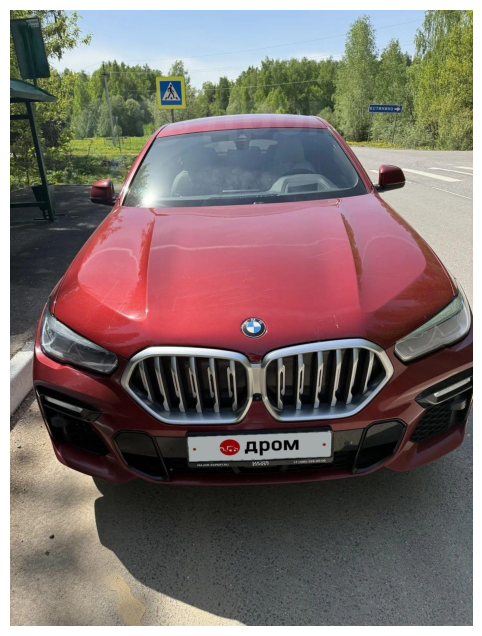

In [194]:
def url_to_image(url):
    image = imageio.imread(url)
    return image

img = url_to_image("data/car_clear_parsed/__yyWwxmEE.jpg")
plt.figure(figsize = (12, 8))
plt.imshow(img)
plt.axis("off");


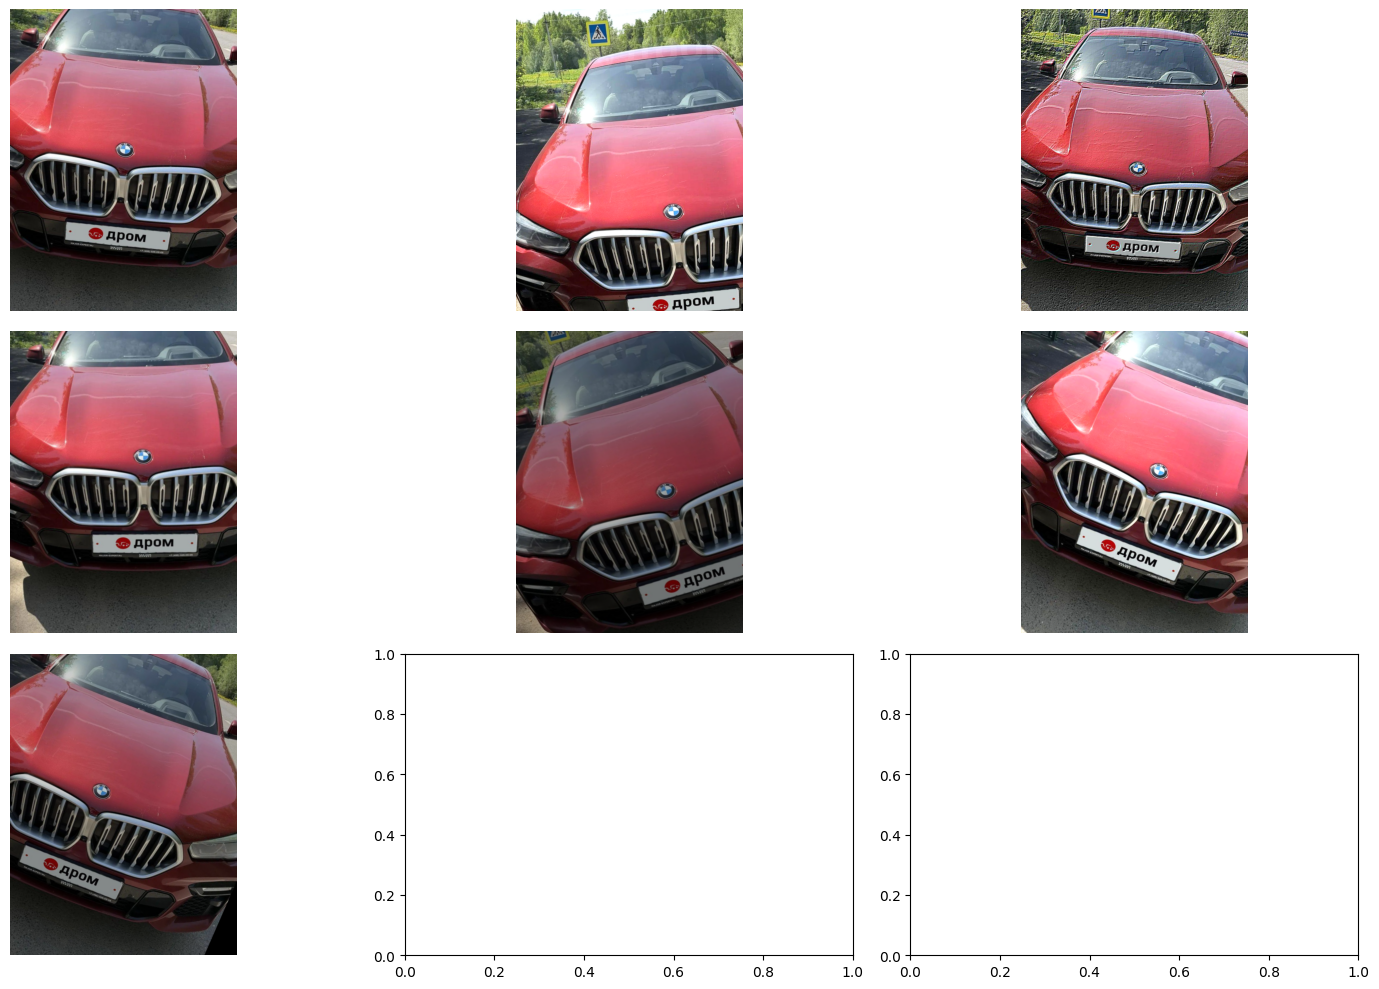

In [197]:
kernals = create_kernals()
new_imgs = apply_img_generation(img, kernals)      # угол от -30 до 30

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, img_filtered in zip(axes.flat, new_imgs):
    ax.imshow(img_filtered)
    ax.axis('off')
plt.tight_layout()
plt.show()

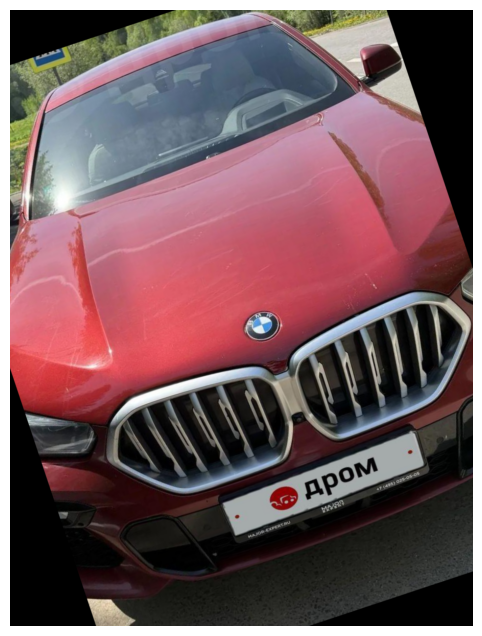

In [196]:
      # масштаб от 1.0 до 1.5

plt.figure(figsize = (12, 8))
plt.imshow(img_rotated_scaled)
plt.axis("off");

In [185]:
!pip install imgdd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.4 MB/s  0:00:00 eta 0:00:01


In [187]:
import imgdd as dd

# Находит все дубликаты в папке (включая вложенные папки)
duplicates = dd.dupes(path="./data/car_clear_parsed")
print(len(duplicates))
# Выводим результат: ключ — хеш, значение — список путей к дубликатам
for hash_value, image_paths in duplicates.items():
    if len(image_paths) > 1:
        print(f"Найдено {len(image_paths)} дубликатов: {image_paths}")

95
Найдено 2 дубликатов: ['./data/car_clear_parsed/kxF5gI0OC1BjYHE.jpg', './data/car_clear_parsed/I0OC1BjYHE.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/9YdW724X7kCWb2e.jpg', './data/car_clear_parsed/24X7kCWb2e.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/jS9LVlS8A6.jpg', './data/car_clear_parsed/CBv8gjS9LVlS8A6.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/ALAL0c_7Pxa6Wfh.jpg', './data/car_clear_parsed/c_7Pxa6Wfh.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/KOYraiA824pIrKJ.jpg', './data/car_clear_parsed/iA824pIrKJ.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/UFlgG0C-m1X3cAo.jpg', './data/car_clear_parsed/0C-m1X3cAo.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/ihv6FmVtm8.jpg', './data/car_clear_parsed/DIR2Vihv6FmVtm8.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/nsdY9a9-a9.jpg', './data/car_clear_parsed/C_eydnsdY9a9-a9.jpg']
Найдено 2 дубликатов: ['./data/car_clear_parsed/OZxOeADG52.jpg', './data/car_clear_parsed/Ym2vVOZxOeA

Failed to open image ./data/car_clear_parsed/.DS_Store: Error decoding image ./data/car_clear_parsed/.DS_Store: The image format could not be determined


In [192]:
# Безопасное удаление: сначала перемещаем в папку backups
backup_dir = "./data/car_clear_parsed/duplicates_backup"
os.makedirs(backup_dir, exist_ok=True)

for dub in duplicates.values():
    try:
        # Перемещаем (можно заменить на os.remove, если уверены)
        # first = dub[0]
        for i in range(1, len(dub)):
            dest = os.path.join(backup_dir, os.path.basename(dub[i]))
            os.rename(dub[i], dest)
            print(f"Удалён (перемещён): {dub[i]}")
    except Exception as e:
        print(f"Ошибка с {dub[i]}: {e}")

Удалён (перемещён): ./data/car_clear_parsed/I0OC1BjYHE.jpg
Удалён (перемещён): ./data/car_clear_parsed/24X7kCWb2e.jpg
Удалён (перемещён): ./data/car_clear_parsed/CBv8gjS9LVlS8A6.jpg
Удалён (перемещён): ./data/car_clear_parsed/c_7Pxa6Wfh.jpg
Удалён (перемещён): ./data/car_clear_parsed/iA824pIrKJ.jpg
Удалён (перемещён): ./data/car_clear_parsed/0C-m1X3cAo.jpg
Удалён (перемещён): ./data/car_clear_parsed/DIR2Vihv6FmVtm8.jpg
Удалён (перемещён): ./data/car_clear_parsed/C_eydnsdY9a9-a9.jpg
Удалён (перемещён): ./data/car_clear_parsed/Ym2vVOZxOeADG52.jpg
Удалён (перемещён): ./data/car_clear_parsed/VlV5I1Smm5jHdlK.jpg
Удалён (перемещён): ./data/car_clear_parsed/SPLtD6aRCd.jpg
Удалён (перемещён): ./data/car_clear_parsed/sWKRug9gAc2UsZ0.jpg
Удалён (перемещён): ./data/car_clear_parsed/RdnmXEUzB3.jpg
Удалён (перемещён): ./data/car_clear_parsed/NB-WaAV94W.jpg
Удалён (перемещён): ./data/car_clear_parsed/CVMJdFCaPpthln4.jpg
Удалён (перемещён): ./data/car_clear_parsed/8x-j8dsUFbzYoW1.jpg
Удалён (перемещё